# [Práctica 3] Fundamentos de Ciencia de Datos
Alejandra Fernández (afernandezm@inf.udec.cl)

# Contenidos
-  **Numpy**
    - Definir arreglos
    - Operaciones con arreglos
    - Acceder a los elementos de un arreglo
    - De DataFrame o Serie a Numpy array
- **Análisis descriptivo**
    - Descripción de datos
      - Centralidad
      - Extensión
    - Matplotlib
        - Cosas básicas : Títulos, limitar ejes, colores, transparencia y etiquetas
        - Lineas en el eje x o y
        - Tipos de gráficos
    - Visualización


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Numpy

NumPy proporciona:
- paquete de extensión a Python para matrices multidimensionales
- eficiencia
- diseñado para computación científica (conveniencia)
- También conocido como computación orientada a arreglos

(Extraido de http://scipy-lectures.org/intro/numpy/array_object.html#what-are-numpy-and-numpy-arrays)

## Definir Arreglos

Podemos definir arreglos multidimensionales *a mano* o de forma *predefinida*.

In [2]:
#Los numpy arrays son otro tipo de dato
print(type(np.array([1,2])))

<class 'numpy.ndarray'>


In [3]:
#Definamos arreglos a mano utilizando listas
n = np.array([1,2,3])
m = np.array([[1,2,3.6],[4,5,6]])
print("n:")
print(n)
print("m:")
print(m)

n:
[1 2 3]
m:
[[1.  2.  3.6]
 [4.  5.  6. ]]


In [4]:
#Podemos obtener las dimensiones, tipos de dato que contiene el arreglo
# y también la "forma" del arreglo, que es el tamaño del arreglo a lo largo de cada dimensión
print('Dimensión de N:',n.ndim,'Tipo de dato:',n.dtype, 'Shape:', n.shape, 'Numero de elementos :', n.size)
print('Dimensión de M:',m.ndim,'Tipo de dato:',m.dtype, 'Shape:', m.shape, 'Numero de elementos :', m.size)

Dimensión de N: 1 Tipo de dato: int64 Shape: (3,) Numero de elementos : 3
Dimensión de M: 2 Tipo de dato: float64 Shape: (2, 3) Numero de elementos : 6


La función len también se puede ocupar sobre arreglos, pero nos entrega el número de "filas"

In [5]:
print(len(m))
len(m) == m.shape[0]

2


True

En un arreglo, todos los elementos son del mismo tipo. Para crear un arreglo de valores tipo float, al menos uno de los valores debe ser un número real.

In [6]:
a = np.array([1,2,3,4])
print(a, "tipo de dato :", a.dtype)
# Agregamos un elemento al final del arreglo ocupando append
a = np.append(a, 4.5)
print(a, "tipo de dato :", a.dtype)

[1 2 3 4] tipo de dato : int64
[1.  2.  3.  4.  4.5] tipo de dato : float64


Algunas funciones predefinidas para crear numpy arrays:
- zeros(n) crea un arreglo de n ceros
- ones(n) crea un arreglo de n unos
- arange(a, b, c) crea un arreglo conteniendo los números entre a y b-1, con un aumento de c.
- linspace(a, b, n) crea un arreglo de n valores entre a y b.

In [7]:
#Matriz de unos
y = np.ones([5,2])
print(y)
print()
#Matriz de ceros
z = np.zeros(5)
print(z)
print()
#Matriz con números al azar
b = np.random.randint(low = 0, high=1000, size = [2,2,2])
print(b)

[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

[0. 0. 0. 0. 0.]

[[[880  29]
  [371 455]]

 [[895 668]
  [609 433]]]


In [8]:
#Podemos modificar las dimensiones del array (siempre considerando el num de elementos que posee)
a = np.ones(10)
b = np.zeros([3,2])
print(a,"Shape de a :", a.shape)
print(b,"Shape de b :", b.shape)
print('*'*50)

a.shape = (5,2)
b = b.reshape(6)
print(a,"Shape de a : ", a.shape)
print(b,"Shape de b : ", b.shape)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.] Shape de a : (10,)
[[0. 0.]
 [0. 0.]
 [0. 0.]] Shape de b : (3, 2)
**************************************************
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]] Shape de a :  (5, 2)
[0. 0. 0. 0. 0. 0.] Shape de b :  (6,)


In [9]:
#b = b.reshape(2)

Podemos crear arreglos definiendo un rango de valores.

In [10]:
#arange(a,b,c) -> inicio:a ; final:b-1 ; salto: c
#Por defecto a=0 y c=1
a = np.arange(10)
print (a)
print("*"*50)
#linespace(a,b,c) -> inicio:a ; final:b ; total de numeros:c
b = np.linspace(5,15,20)
print (b)

[0 1 2 3 4 5 6 7 8 9]
**************************************************
[ 5.          5.52631579  6.05263158  6.57894737  7.10526316  7.63157895
  8.15789474  8.68421053  9.21052632  9.73684211 10.26315789 10.78947368
 11.31578947 11.84210526 12.36842105 12.89473684 13.42105263 13.94736842
 14.47368421 15.        ]


## Operaciones con arreglos
Una de las ventajas de trabajar con NumPy son las operaciones que podemos hacer sobre arreglos.
Las operaciones aritméticas entre arreglos se aplican elemento a elemento.

Importante: Cuando dos arreglos aparecen en una operación, ambos deben tener exactamente la misma forma

In [11]:
#Tengo los siguientes conjuntos de numeros
a = np.array([0.1,0.3,2.4,2.5,0.9,0.6,0.4,0.6])
b = np.array([1,1.3,1.7,1.9,1.5,1.0,0.9,0.6])

In [12]:
a.size

8

In [13]:
b.size

8

In [14]:
# sumar elemento a elemento
x = a + b
print(x)

# multiplicar elemento a elemento
y = a * b
print(y)

# restar elemento a elemento
y = a - b
print(y)

[1.1 1.6 4.1 4.4 2.4 1.6 1.3 1.2]
[0.1  0.39 4.08 4.75 1.35 0.6  0.36 0.36]
[-0.9 -1.   0.7  0.6 -0.6 -0.4 -0.5  0. ]


In [15]:
c = np.array([0.2, 0.3])
print(c.size)

2


In [16]:
#a + c

In [17]:
# Sumar una cantidad a todos los elementos del arreglo
a = a + 5.0
print(a)
# Multiplicar por una cantidad todos los elementos del arreglo
b = b * 0.25
print(b)

[5.1 5.3 7.4 7.5 5.9 5.6 5.4 5.6]
[0.25  0.325 0.425 0.475 0.375 0.25  0.225 0.15 ]


In [18]:
media = np.mean(x)
print("La media de los valores de x es :", media)
suma = np.sum(x)
print("La suma de los valores de x es :", suma)
prod = np.prod(x)
print("La multiplicación de los valores de x es :", prod)
std = np.std(x)
print("La desviación estandar de los valores de x es :", std)
max = np.max(x)
print("El valor máximo en x es :", max)
xargmax = np.argmax(x)
print("El valor máximo en x está en la posición :", xargmax)

La media de los valores de x es : 2.2125
La suma de los valores de x es : 17.7
La multiplicación de los valores de x es : 190.19759616000005
La desviación estandar de los valores de x es : 1.2363631141375901
El valor máximo en x es : 4.4
El valor máximo en x está en la posición : 3


In [19]:
#Transpuesta de una matriz
a = np.array([[1,2,3],[4,5,6],[7,8,9]])
print(a)
print()
print(a.T)

[[1 2 3]
 [4 5 6]
 [7 8 9]]

[[1 4 7]
 [2 5 8]
 [3 6 9]]


In [20]:
#Ordenar
a = np.array([[9,6,3],[8,5,2],[7,4,1]])
a = np.sort(a)
print(a)

[[3 6 9]
 [2 5 8]
 [1 4 7]]


Con arreglos de mas de una dimensión podemos definir si queremos que la operación se haga por filas o por columnas.

In [21]:
np.random.seed(24) #Para que salgan los mismos números

#Tengo los siguientes conjuntos de numeros
a = np.random.randint(500, size = [3,4])
print(a)
print("Sumar todos los numeros :", a.sum())
print("Sumar las columnas :", a.sum(0))
print("Sumar las filas :", a.sum(1))

[[418 387 192 343]
 [401 145 129 356]
 [123 207   4 495]]
Sumar todos los numeros : 3200
Sumar las columnas : [ 942  739  325 1194]
Sumar las filas : [1340 1031  829]


In [22]:
print("Valor mas pequeño en el arreglo", a.min())
print("Valores mas pequeño por columna", a.min(0))
print("Valores mas pequeño por fila", a.min(1))

Valor mas pequeño en el arreglo 4
Valores mas pequeño por columna [123 145   4 343]
Valores mas pequeño por fila [192 129   4]


## Acceder a los elementos de un arreglo
Igual que en el caso de las listas, cada elemento en el arreglo tiene un índice y el primer elemento tiene índice 0.

Los elementos también pueden numerarse desde el final hacia el principio utilizando índices negativos, donde el último elemento tiene índice -1.

In [23]:
#Definimos un arreglo
a = np.random.randint(500, size = 20)
print(a)
#Indexing
primer_elemento = a[0]
print("Primer elemento del arreglo :", primer_elemento)
quinto_elemento = a[4]
print("Quinto elemento del arreglo :", quinto_elemento)
ultimo_elemento = a[-1]
print("Último elemento del arreglo :", ultimo_elemento)
penultimo_elemento = a[-2]
print("Penúltimo elemento del arreglo :", penultimo_elemento)


[227 338 395 379 483 371 399 231 329 274 375 391 409 163 493 223  28 384
 254  12]
Primer elemento del arreglo : 227
Quinto elemento del arreglo : 483
Último elemento del arreglo : 12
Penúltimo elemento del arreglo : 254


In [24]:
#Slicing
print(a[1:4])
print(a[:-2])
print(a[2:])

[338 395 379]
[227 338 395 379 483 371 399 231 329 274 375 391 409 163 493 223  28 384]
[395 379 483 371 399 231 329 274 375 391 409 163 493 223  28 384 254  12]


In [25]:
#Indexing y Slicing con arreglo bidimensional
np.random.seed(24) #Para que salgan los mismos números

#Tengo los siguientes conjuntos de numeros
a = np.random.randint(500, size = [3,4,2])
print(a)

[[[418 387]
  [192 343]
  [401 145]
  [129 356]]

 [[123 207]
  [  4 495]
  [227 338]
  [395 379]]

 [[483 371]
  [399 231]
  [329 274]
  [375 391]]]


In [26]:
a[1][1][0]

np.int64(4)

In [27]:
print("Primer elemento", a[0][0][0])
print("Último elemento", a[-1][-1][-1])

Primer elemento 418
Último elemento 391


## De DataFrame o Serie a Numpy array

In [28]:
dataset = {
    "Columna1": [4,5,10,20,34,56,2],
    "Columna2": [10,20,30,40,50,60,60],
    "Columna3": [1,2,3,4,5,6,7]
}

data = pd.DataFrame(dataset)
data

,Columna1,Columna2,Columna3
0,4,10,1
1,5,20,2
2,10,30,3
3,20,40,4
4,34,50,5
5,56,60,6
6,2,60,7


In [29]:
data.values

array([[ 4, 10,  1],
       [ 5, 20,  2],
       [10, 30,  3],
       [20, 40,  4],
       [34, 50,  5],
       [56, 60,  6],
       [ 2, 60,  7]])

In [30]:
data.to_numpy()

array([[ 4, 10,  1],
       [ 5, 20,  2],
       [10, 30,  3],
       [20, 40,  4],
       [34, 50,  5],
       [56, 60,  6],
       [ 2, 60,  7]])

# Análisis Descriptivo

Vamos a utilizar un dataset que corresponde a un fragmento de el dataset oficial de Colisiones de Seattle que contiene todas las colisiones proporcionadas por la Policía de Seattle (SPD) y registradas por el Departamento de Registros de Tráfico.

Descripción de columnas de interes:
- **X / Y**: Coordenadas proyectadas para visualización geoespacial.
- **COLLISIONTYPE**: Tipo de colisión.
- **LOCATION** : Descripción de la ubicación general de la colisión.
- **SEVERITYCODE**: Código que corresponde a la gravedad de la colisión:
(3 — fatalidad, 2b — lesión grave, 2 — lesión, 1 — daño a la propiedad, 0 — desconocido)
- **SEVERITYDESC**: Descripción detallada de la gravedad de la colisión ['Injury Collision', 'Unknown', 'Property Damage Only Collision', 'Serious Injury Collision', 'Fatality Collision']
- **PERSONCOUNT**: Número total de personas involucradas en la colisión
- **PEDCOUNT**: Número de peatones involucrados en la colisión
- **PEDCYLCOUNT**: Número de bicicletas involucradas en la colisión
- **VEHCOUNT**: Número de vehículos involucrados en la colisión
- **INJURIES**: Número total de personas lesionadas en la colisión
- **SERIOUSINJURIES**: Número de lesiones graves en la colisión
- **FATALITIES**: Número de muertes en la colisión
- **INCDATE**: Fecha del incidente.
- **INCDTTM**: Fecha y hora del incidente.
- **INATTENTIONIND**: Si la colisión fue causada por falta de atención (Y/N).
- **UNDERINFL**: Si algún conductor involucrado estaba bajo la influencia de drogas o alcohol.
- **WEATHER**: Una descripción de las condiciones climáticas al momento de la colisión.
- **ROADCOND**:La condición de la vía durante la colisión.
- **LIGHTCOND**: Las condiciones de iluminación durante la colisión.
- **PEDROWNOTGRNT**: Indica si **no se respetó el derecho de paso del peatón** (Y/N)
- **SPEEDING**: Indica si el **exceso de velocidad** fue un factor en la colisión (Y/N)                                     
- **HITPARKEDCAR** : Indica si el accidente involucró un choque contra un vehículo estacionado (Y/N)

## Descripción de los datos

In [31]:
# importamos las librerías, le damos un seudonimo a las librerias para mejorar
# legibilidad en el código.
import numpy as np
import pandas as pd
import datetime
from IPython.display import display #Para mostrar la tabla de pandas (No es necesario)

In [32]:
columnas_interes = [
    "X",
    "Y",
    "COLLISIONTYPE",
    "LOCATION",
    "SEVERITYCODE",
    "SEVERITYDESC",
    "PERSONCOUNT",
    "PEDCOUNT",
    "PEDCYLCOUNT",
    "VEHCOUNT",
    "INJURIES",
    "SERIOUSINJURIES",
    "FATALITIES",
    "INCDATE",
    "INCDTTM",
    "INATTENTIONIND",
    "UNDERINFL",
    "WEATHER",
    "ROADCOND",
    "LIGHTCOND",
    "PEDROWNOTGRNT",
    "SPEEDING",
    "HITPARKEDCAR"
]

In [33]:
# Cargar el dataset de accidentes de tránsito
accidentes = pd.read_csv("https://raw.githubusercontent.com/anmol-tripathi/SDOT_Collision_Analysis/refs/heads/master/Collisions.csv")
accidentes = accidentes[columnas_interes]
accidentes.head(10)

,X,Y,COLLISIONTYPE,LOCATION,SEVERITYCODE,SEVERITYDESC,PERSONCOUNT,PEDCOUNT,PEDCYLCOUNT,VEHCOUNT,...,INCDATE,INCDTTM,INATTENTIONIND,UNDERINFL,WEATHER,ROADCOND,LIGHTCOND,PEDROWNOTGRNT,SPEEDING,HITPARKEDCAR
0,-122.392900,47.648646,Rear Ended,28TH AVE W AND W DRAVUS ST,2,Injury Collision,2,0,0,2,...,2020/06/09 00:00:00+00,06-09-2020 12:48,NaN,N,Overcast,Dry,Daylight,NaN,NaN,N
1,-122.284487,47.603308,NaN,LAKE WASHINGTON BLVD BETWEEN LAKESIDE AVE AND ...,0,Unknown,0,0,0,0,...,2020/02/02 00:00:00+00,02-02-2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y
2,-122.338480,47.619118,Sideswipe,WESTLAKE AVE N BETWEEN DENNY WAY AND JOHN ST,1,Property Damage Only Collision,2,0,0,2,...,2020/02/12 00:00:00+00,02-12-2020 08:00,NaN,N,Clear,Dry,Daylight,NaN,NaN,N
3,-122.358307,47.653110,Parked Car,NW 36TH ST BETWEEN 1ST AVE NW AND LEARY WAY NW,1,Property Damage Only Collision,4,0,0,4,...,2020/01/23 00:00:00+00,1/23/2020 10:33:00 PM,NaN,N,Raining,Wet,Dark - Street Lights On,NaN,NaN,Y
4,-122.296519,47.733786,Angles,30TH AVE NE AND NE 145TH ST,2,Injury Collision,2,0,0,2,...,2019/11/26 00:00:00+00,11/26/2019 8:26:00 AM,Y,N,Clear,Dry,Daylight,NaN,NaN,N
5,-122.353952,47.689837,Rear Ended,N 84TH ST BETWEEN GREENWOOD AVE N AND DAYTON A...,1,Property Damage Only Collision,3,0,0,2,...,2013/03/25 00:00:00+00,3/25/2013 6:46:00 PM,NaN,Y,Clear,Dry,Daylight,NaN,NaN,N
6,-122.385554,47.570186,Other,42ND AVE SW AND SW CHARLESTOWN ST,1,Property Damage Only Collision,1,0,0,1,...,2020/06/21 00:00:00+00,6/21/2020 12:30:00 AM,NaN,N,Clear,Dry,Dark - Street Lights On,NaN,Y,N
7,-122.343536,47.628896,NaN,AURORA AVE N AND PROSPECT ST,0,Unknown,0,0,0,0,...,2016/01/21 00:00:00+00,1/21/2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
8,-122.303396,47.572507,Angles,23RD AVE S BETWEEN S HINDS ST AND S SPOKANE ST,1,Property Damage Only Collision,2,0,0,2,...,2020/01/23 00:00:00+00,1/23/2020 2:19:00 PM,NaN,N,Raining,Wet,Daylight,NaN,Y,N
9,-122.345095,47.733973,NaN,AURORA AVE N BETWEEN ROOSEVELT WAY N AND N 145...,2,Injury Collision,2,0,0,0,...,2020/02/01 00:00:00+00,02-01-2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N


In [34]:
accidentes.columns

Index(['X', 'Y', 'COLLISIONTYPE', 'LOCATION', 'SEVERITYCODE', 'SEVERITYDESC',
       'PERSONCOUNT', 'PEDCOUNT', 'PEDCYLCOUNT', 'VEHCOUNT', 'INJURIES',
       'SERIOUSINJURIES', 'FATALITIES', 'INCDATE', 'INCDTTM', 'INATTENTIONIND',
       'UNDERINFL', 'WEATHER', 'ROADCOND', 'LIGHTCOND', 'PEDROWNOTGRNT',
       'SPEEDING', 'HITPARKEDCAR'],
      dtype='object')

In [35]:
accidentes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220937 entries, 0 to 220936
Data columns (total 23 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   X                213471 non-null  float64
 1   Y                213471 non-null  float64
 2   COLLISIONTYPE    194666 non-null  object 
 3   LOCATION         216354 non-null  object 
 4   SEVERITYCODE     220936 non-null  object 
 5   SEVERITYDESC     220937 non-null  object 
 6   PERSONCOUNT      220937 non-null  int64  
 7   PEDCOUNT         220937 non-null  int64  
 8   PEDCYLCOUNT      220937 non-null  int64  
 9   VEHCOUNT         220937 non-null  int64  
 10  INJURIES         220937 non-null  int64  
 11  SERIOUSINJURIES  220937 non-null  int64  
 12  FATALITIES       220937 non-null  int64  
 13  INCDATE          220937 non-null  object 
 14  INCDTTM          220937 non-null  object 
 15  INATTENTIONIND   30188 non-null   object 
 16  UNDERINFL        194686 non-null  obje

### Centralidad

In [36]:
#Para valores numericos ocuparemos la columna PERSONCOUNT, que indica cuántas personas estuvieron involucradas en cada accidente.
print("Media:", accidentes["PERSONCOUNT"].mean())
print("Mediana:", accidentes["PERSONCOUNT"].median())

Media: 2.2267705273448994
Mediana: 2.0


Observamos que la media y la mediana no son iguales, analizaremos esto mas en profundidad con la extensión de los datos

In [37]:
#Como ejemplo para las variables no categoricas, utilizaremos la columna "weather"
accidentes["WEATHER"].unique()

array(['Overcast', nan, 'Clear', 'Raining', 'Unknown', 'Fog/Smog/Smoke',
       'Other', 'Snowing', 'Partly Cloudy', 'Sleet/Hail/Freezing Rain',
       'Blowing Sand/Dirt', 'Severe Crosswind', 'Blowing Snow'],
      dtype=object)

In [38]:
accidentes["WEATHER"].mode()

,WEATHER
0,Clear


In [39]:
accidentes["WEATHER"].value_counts()

,count
WEATHER,
Clear,114293
Raining,34004
Overcast,28495
Unknown,15131
Snowing,919
Other,851
Fog/Smog/Smoke,576
Sleet/Hail/Freezing Rain,116
Blowing Sand/Dirt,56


### Extensión

Recordemos que la media y mediana de "PERSONCOUNT" eran diferentes (aunque bastante cercanas)

In [40]:
#Usemos la columna PERSONCOUNT para el ejemplo

#Rango
print("Min:", accidentes["PERSONCOUNT"].min())
print("Max:", accidentes["PERSONCOUNT"].max())

#Varianza
print("Varianza:", accidentes["PERSONCOUNT"].var())

#Desv. estandar
print("std:", accidentes["PERSONCOUNT"].std())

Min: 0
Max: 93
Varianza: 2.163732225797932
std: 1.4709630266590428


Vemos que el rango es bastante extenso y el valor maximo es muy superior a la media y a la mediana.

In [41]:
media =  accidentes["PERSONCOUNT"].mean()
mediana = accidentes["PERSONCOUNT"].median()
max =  accidentes["PERSONCOUNT"].max()
print("Media:",media, "Mediana:",mediana, "Maximo:",max)

Media: 2.2267705273448994 Mediana: 2.0 Maximo: 93


Para entender si solo es un accidente el que involucra tantas personas o si son varios, utilizaremos los percentiles

In [42]:
#Percentiles
quantile_25 = accidentes["PERSONCOUNT"].quantile(0.25)
quantile_50 = accidentes["PERSONCOUNT"].quantile(0.5)
quantile_75 = accidentes["PERSONCOUNT"].quantile(0.75)
print("Percentil 25%:", quantile_25)
print("Percentil 50% (mediana):", quantile_50)
print("Percentil 75%:", quantile_75)

Percentil 25%: 2.0
Percentil 50% (mediana): 2.0
Percentil 75%: 3.0


Vemos que el 75% de las colisiones involucra a 3 personas o menos

In [43]:
accidentes["PERSONCOUNT"].quantile(0.95)

np.float64(5.0)

Vemos que deben ser casos alejados de lo tipico en las colisiones ya que un 95% de las colisiones involucran 5 personas o menos

### Describe

In [44]:
accidentes.shape

(220937, 23)

In [45]:
accidentes.describe()

,X,Y,PERSONCOUNT,PEDCOUNT,PEDCYLCOUNT,VEHCOUNT,INJURIES,SERIOUSINJURIES,FATALITIES
count,213471.000000,213471.000000,220937.000000,220937.000000,220937.000000,220937.000000,220937.000000,220937.000000,220937.000000
mean,-122.330751,47.620212,2.226771,0.038138,0.027306,1.730272,0.373840,0.015167,0.001684
std,0.030052,0.056025,1.470963,0.201816,0.164385,0.829913,0.732188,0.158010,0.044595
min,-122.419091,47.495573,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-122.349280,47.577331,2.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000
50%,-122.330363,47.616078,2.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000
75%,-122.311998,47.664261,3.000000,0.000000,0.000000,2.000000,1.000000,0.000000,0.000000
max,-122.238949,47.734142,93.000000,6.000000,2.000000,15.000000,78.000000,41.000000,5.000000


In [46]:
accidentes.describe(include = "object")

,COLLISIONTYPE,LOCATION,SEVERITYCODE,SEVERITYDESC,INCDATE,INCDTTM,INATTENTIONIND,UNDERINFL,WEATHER,ROADCOND,LIGHTCOND,PEDROWNOTGRNT,SPEEDING,HITPARKEDCAR
count,194666,216354,220936,220937,220937,220937,30188,194686,194477,194557,194389,5186,9898,220937
unique,10,25183,5,5,6068,169013,1,4,12,9,9,1,1,2
top,Parked Car,BATTERY ST TUNNEL NB BETWEEN ALASKAN WY VI NB ...,1,Property Damage Only Collision,2006/11/02 00:00:00+00,11-02-2006,Y,N,Clear,Dry,Daylight,Y,Y,N
freq,48445,298,137297,137297,103,103,30188,103381,114293,128092,119082,5186,9898,209021


## Matplotlib

Para hacer los gráficos utilizaremos la libreria matplotlib

In [47]:
#La importaremos asi
import matplotlib.pyplot as plt

### Cosas básicas


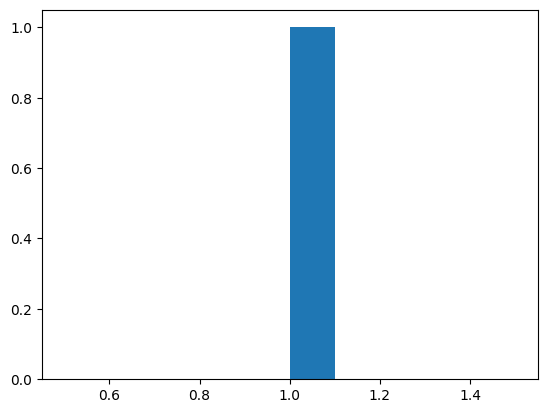

In [48]:
#Para partir simplemente utilizaremos un histograma de ejemplo
plt.hist(1)
plt.show()

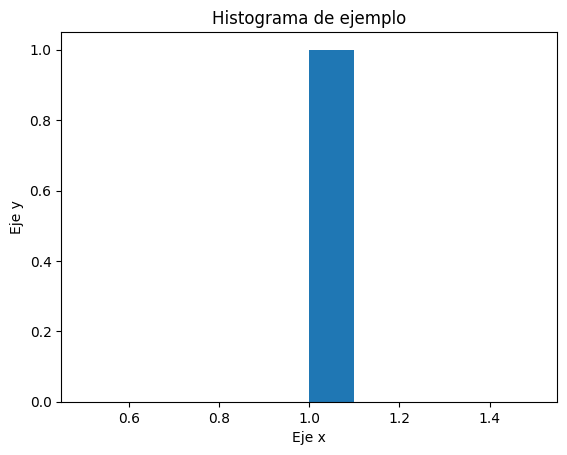

In [49]:
#Titulo y nombres eje x, eje y
plt.hist(1)
plt.title("Histograma de ejemplo")
plt.xlabel("Eje x")
plt.ylabel("Eje y")
plt.show()

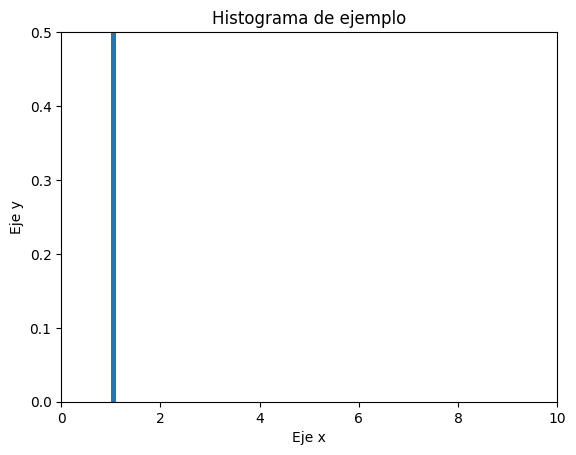

In [50]:
#Limitar eje x o y
plt.hist(1)
plt.title("Histograma de ejemplo")
plt.xlabel("Eje x")
plt.ylabel("Eje y")
plt.xlim([0,10])
plt.ylim([0,0.5])
plt.show()

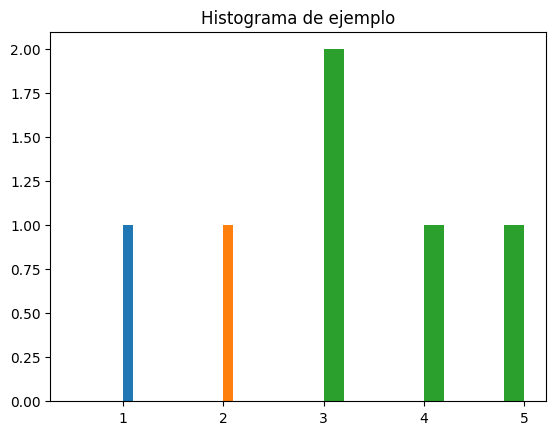

In [51]:
#Colores
#Al agregar mas de una "figura" en un mismo grafico, estas se van poniendo de colores distintos
plt.hist(1)
plt.hist([2])
plt.hist([3,3,4,5])
plt.title("Histograma de ejemplo")
plt.show()

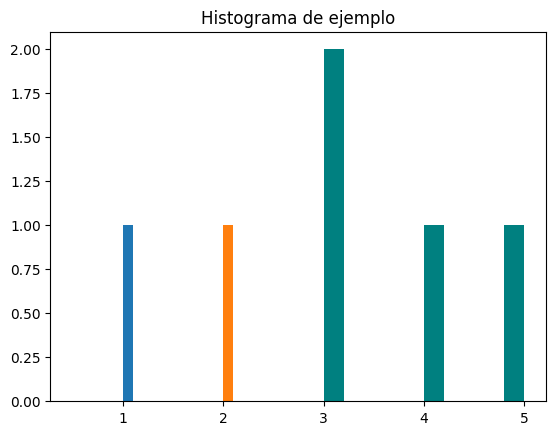

In [52]:
#Colores
#Para cambiar especificamente el color de una, se utiliza el parámetro color
plt.hist(1)
plt.hist([2])
plt.hist([3,3,4,5], color = "teal")
plt.title("Histograma de ejemplo")
plt.show()

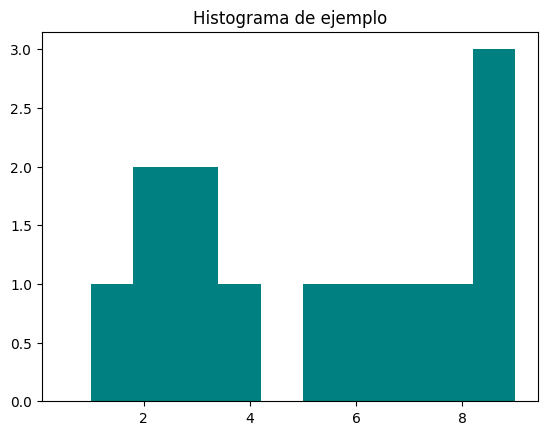

In [53]:
#Transparencia
#En algunas ocasiones tendremos figuras que esten tapando a otras
plt.hist(1)
plt.hist([2])
plt.hist([1,2,2,3,3,4,5,6,7,8,9,9,9], color = "teal")
plt.title("Histograma de ejemplo")
plt.show()

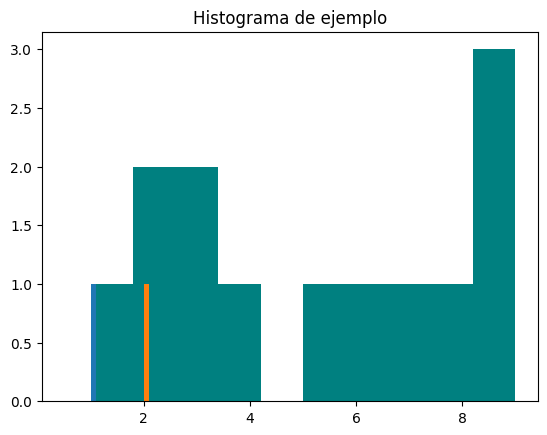

In [54]:
#Transparencia
#En algunas ocasiones tendremos figuras que esten tapando a otras
#Las figuras aparecen en el orden en que estan en el codigo
plt.hist([1,2,2,3,3,4,5,6,7,8,9,9,9], color = "teal")
plt.hist(1)
plt.hist([2])
plt.title("Histograma de ejemplo")
plt.show()

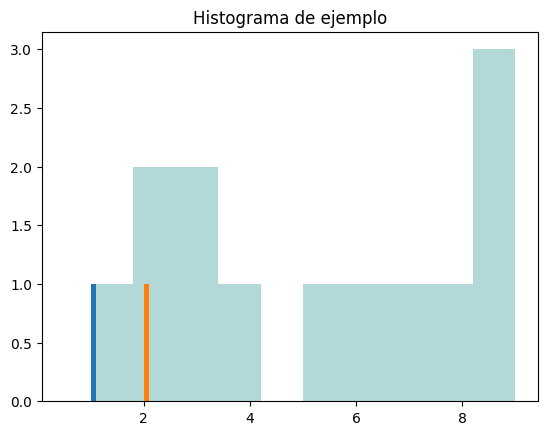

In [55]:
#Aun la azul no se ve, para esto podemos utilizar el parametro alpha
plt.hist([1,2,2,3,3,4,5,6,7,8,9,9,9], color = "teal", alpha=0.3)
plt.hist(1)
plt.hist([2])
plt.title("Histograma de ejemplo")
plt.show()

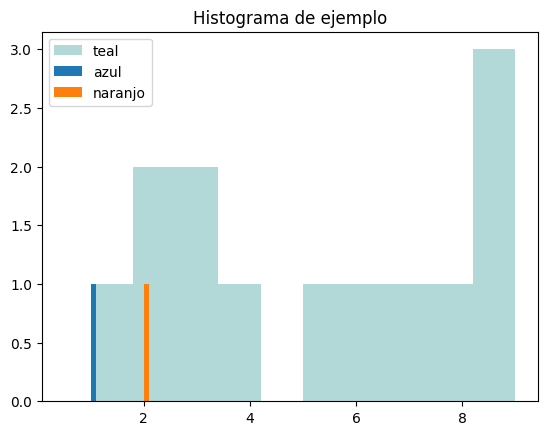

In [56]:
#Etiquetas
#Podemos agregar etiquetas a la distribución con el parametro label
#Para que estas aparezcan hay que colocar "plt.legend()"
plt.hist([1,2,2,3,3,4,5,6,7,8,9,9,9], color = "teal", alpha=0.3, label="teal")
plt.hist(1, label="azul")
plt.hist([2], label="naranjo")
plt.title("Histograma de ejemplo")
plt.legend()
plt.show()

### Lineas en el eje x o y

Para colocar una linea paralela al eje x utilizamos axhline y para colocar una linea paralela al eje y utilizamos axvline

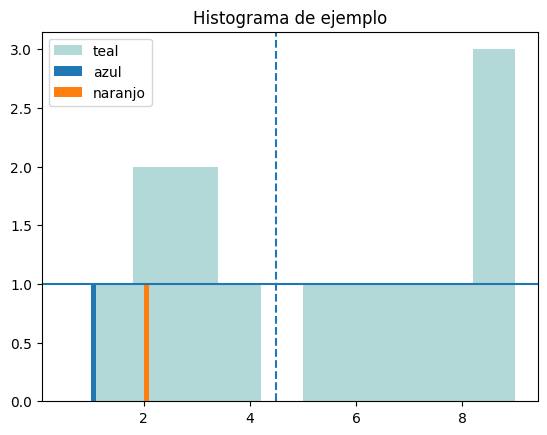

In [57]:
plt.hist([1,2,2,3,3,4,5,6,7,8,9,9,9], color = "teal", alpha=0.3, label="teal")
plt.hist(1, label="azul")
plt.hist([2], label="naranjo")
plt.axhline(1)
plt.axvline(4.5, ls="--")
plt.title("Histograma de ejemplo")
plt.legend()
plt.show()

### Tipos de graficos

Dataset: Calidad del aire (NO2)
Medidas de NO2 de las estaciones FR04014, BETR801 y London Westminster que se encuentran en Paris, Antwerp y Londres, respectivamente.

In [59]:
df = pd.read_csv('https://raw.githubusercontent.com/pandas-dev/pandas/master/doc/data/air_quality_no2.csv', index_col=0, parse_dates=True)
df.head()

,station_antwerp,station_paris,station_london
datetime,,,
2019-05-07 02:00:00,NaN,NaN,23.0
2019-05-07 03:00:00,50.5,25.0,19.0
2019-05-07 04:00:00,45.0,27.7,19.0
2019-05-07 05:00:00,NaN,50.4,16.0
2019-05-07 06:00:00,NaN,61.9,NaN


#### Plot

Gráfico de lineas
En este caso nos sirve para ver el comportamiento de NO2 en el tiempo

<Axes: xlabel='datetime'>

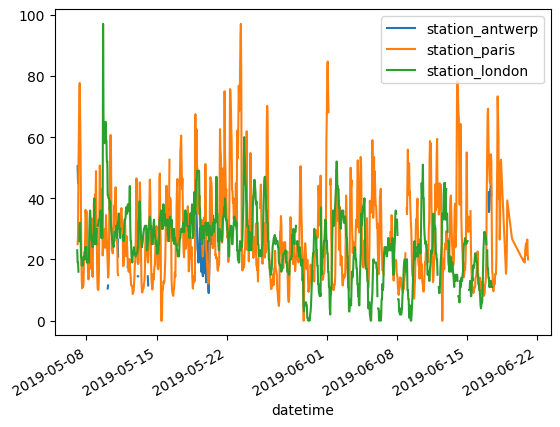

In [60]:
df.plot()

#### Histograma

Muestra la frecuencia de distribucion de los datos. En ellos se pueden observar los peaks, si la distribución está sesgada, si es uniforme, normal, entre otros.

¿Como escogemos el número/tamaño de bins?

Si asumimos una distribución Gaussiana:
- Scott's rule: $h=3.5\sigma/N^{1/3}$, donde $\sigma$ es la desviación estandar de las muestras y $N$ es el número de datos
- Distribuciones no Gaussianas: Freedman-Diaconis rule: $h= 2(q_{75}-q_{25})/N^{1/3}$, donde $q_{75}$ y $q_{25}$ son los cuartiles 75 and 25 respectivamente.
- cross-validation (mas costosa)

En ```plt.hist``` podemos asignar en el argumento ```bins``` los siguientes strings: ```'auto', 'fd', 'doane', 'scott', 'stone', 'rice', 'sturges', or 'sqrt'```. En donde se aplican distintas técnicas para calcular el tamaño optimo de bins.

<Axes: >

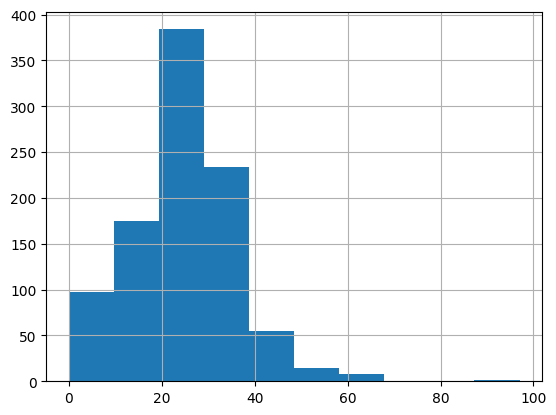

In [61]:
df["station_london"].hist()

#### Scatter
Los scatter plots se utilizan para observar y mostrar relaciones entre dos variables numéricas. Los puntos en el gráfico no sólo reportan el valor individual de cada uno de los puntos, si no que también muestran patrones cuando los datos son tomados como un todo.

Podemos observar agrupamientos, outliers, vacíos en los datos, relaciones lineales, entre otros.

<Axes: xlabel='station_london', ylabel='station_paris'>

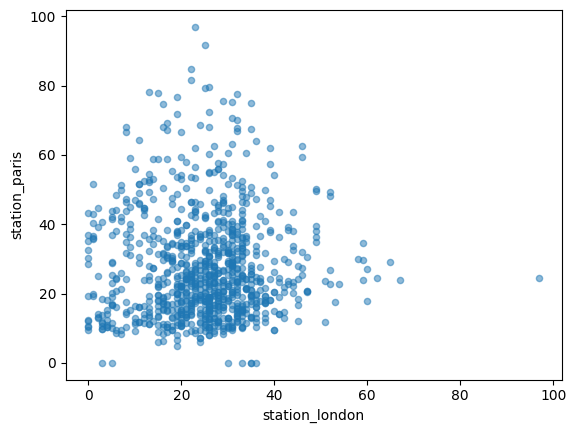

In [62]:
df.plot.scatter(x="station_london", y="station_paris", alpha=0.5)

#### Box plot (Caracterización de cada columna)

Sirve para identificar si hay datos atipicos.

El box plot utiliza cajas y lineas para ilustrar la distribución de uno o más grupos de datos numéricos. Su elaboración está basada en cuartiles, en donde la línea central es la mediana (Q2, 50% de los datos) y los límites de la caja superior e inferior corresponden a Q1 (25% de los datos) y Q3 (75% de los datos), respectivamente.

Las líneas que salen de la caja representan al valor máximo y mínimo.
Los puntos que salen del gráfico corresponden a los datos atípicos (outliers).

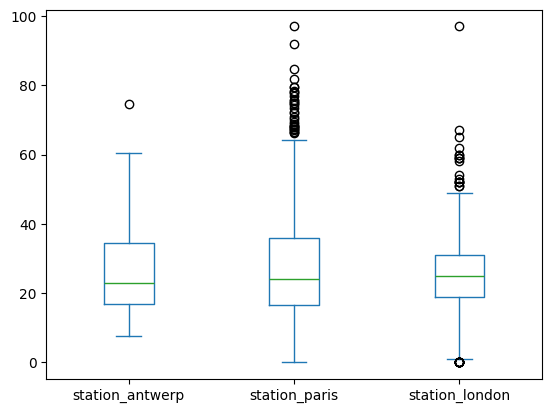

In [63]:
df.plot.box();

#### Gráfico para cada columna (Gráfico de área)

Se utiliza en series de tiempo cuando se quieren observar como un todo o por separado. Permite detectar sobrelapes, como cada uno de los componentes contribuye al total, entre otros.

<Axes: xlabel='datetime'>

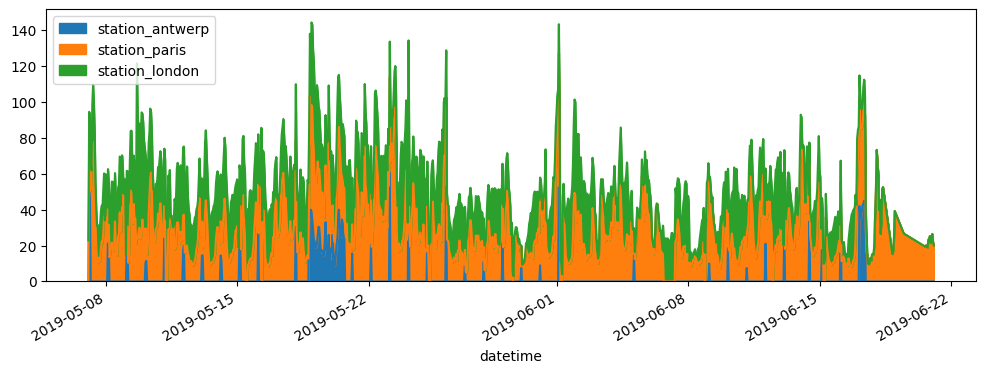

In [64]:
df.plot.area(figsize=(12, 4))

#### Gráfico de barras

En un gráfico de barras se muestran distintas variables categóricas, cada una representada por una barra. Este gráfico se utiliza cuando se quiere mostrar la distribución de los datos o cuando se quiere hacer una comparacion entre las distintas variables categóricas.

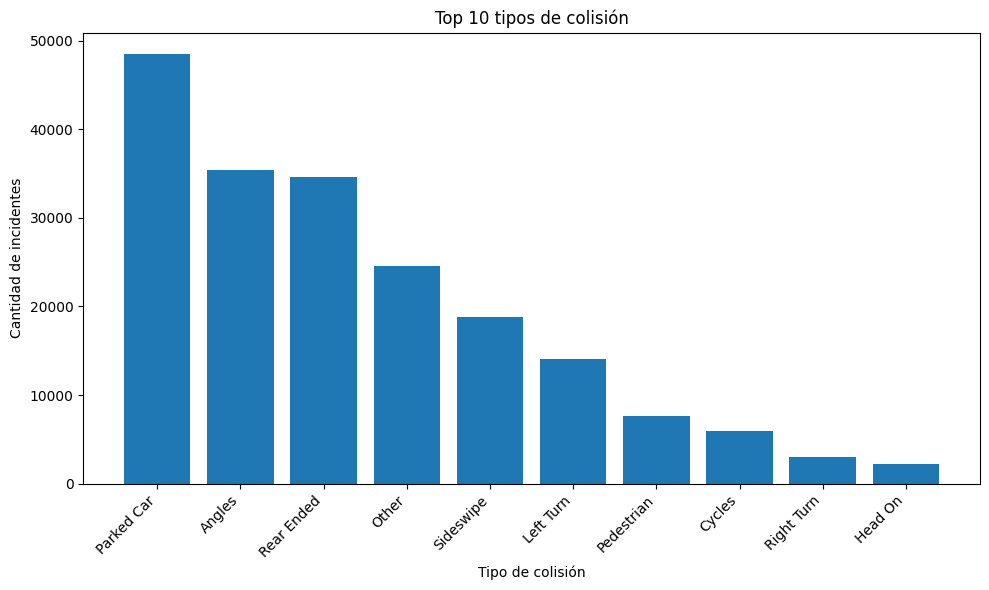

In [65]:
# Top 10 tipos de colisión
collision_counts = accidentes["COLLISIONTYPE"].value_counts().head(10)

plt.figure(figsize=(10,6))
plt.bar(collision_counts.index, collision_counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 tipos de colisión")
plt.xlabel("Tipo de colisión")
plt.ylabel("Cantidad de incidentes")
plt.tight_layout()
plt.show()

<BarContainer object of 10 artists>

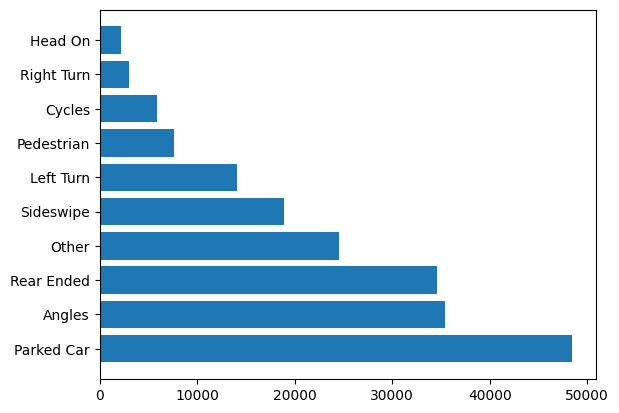

In [66]:
plt.barh(collision_counts.index, collision_counts.values)

#### Gráfico de torta

Muestra como el total se divide en las distintas categorías. El tamaño indica la proporción de la categoría con respecto al total.

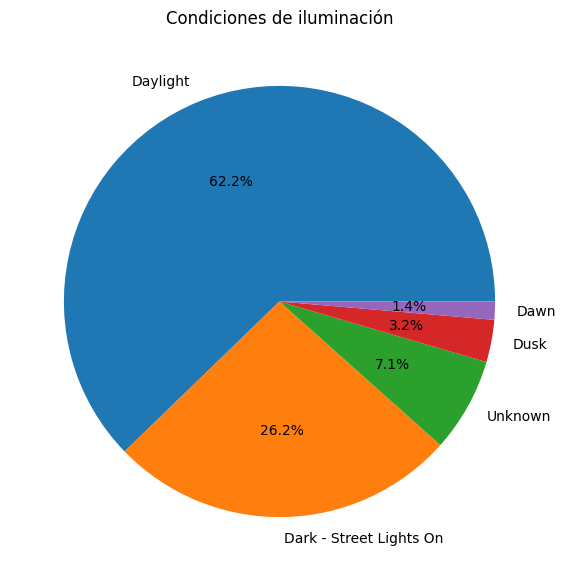

In [67]:
plt.figure(figsize=(7,7))
accidentes["LIGHTCOND"].value_counts().head(5).plot.pie(autopct="%1.1f%%")
plt.title("Condiciones de iluminación")
plt.ylabel("")  # Ocultar etiqueta de eje y
plt.show()

Text(0.5, 1.0, 'Condiciones de iluminación (top 5)')

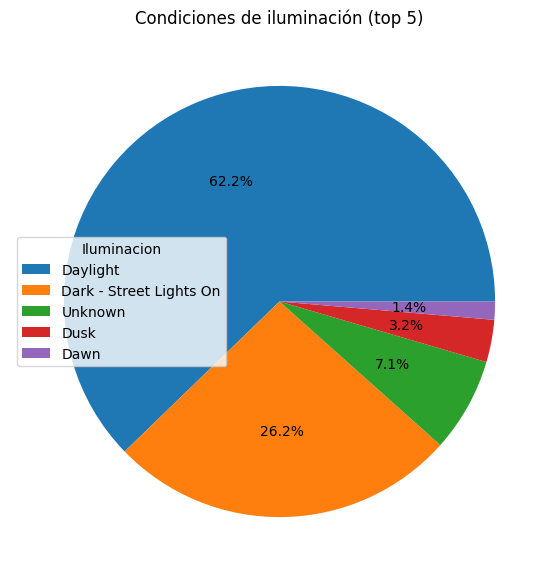

In [68]:
iluminacion = accidentes["LIGHTCOND"].value_counts().head(5)
plt.figure(figsize=(7,7))
plt.pie(iluminacion, labels=None, autopct="%1.1f%%")
plt.legend(labels=iluminacion.index, title="Iluminacion", loc="center left") # bbox_to_anchor=(1, 0.5))
plt.title("Condiciones de iluminación (top 5)")

# Ejercicios

# Problema 1 (En conjunto)

Hacer un histograma de la variable "PERSONCOUNT" con una linea vertical que indique la media

(RESTRINGIR RANGO ENTRE 0 Y 10, bins = "fd")

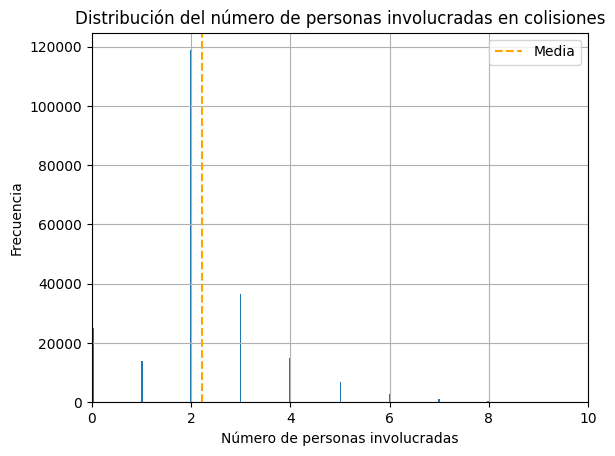

In [72]:
accidentes["PERSONCOUNT"].hist(bins="fd")

plt.xlim([0, 10])

# Líneas verticales para la media
plt.axvline(accidentes["PERSONCOUNT"].mean(), label="Media", ls="--", color="orange")


plt.legend()
plt.title("Distribución del número de personas involucradas en colisiones")
plt.xlabel("Número de personas involucradas")
plt.ylabel("Frecuencia")
plt.show()

## Problema 2

Haz un gráfico de barras que muestre el número de colisiones por tipo de colisión (COLLISIONTYPE). Tambien se pide:

- Ordenar las categorías de mayor a menor frecuencia.

- Rotar las etiquetas del eje X en 45 grados.

- Agregar título y nombres de ejes.

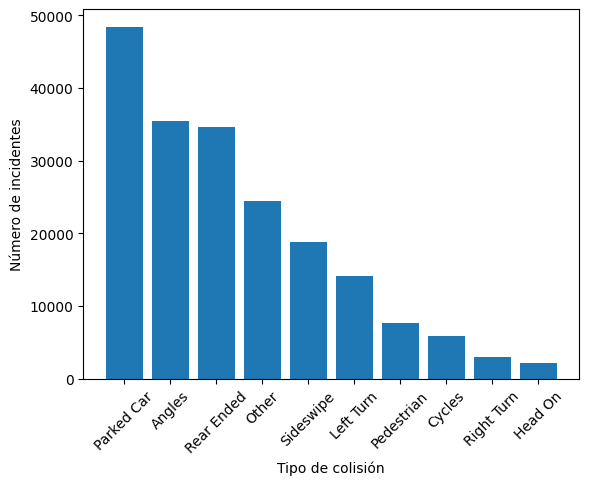

In [73]:
conteo_tipo = accidentes["COLLISIONTYPE"].value_counts()
plt.bar(conteo_tipo.index, conteo_tipo.values)
plt.xticks(rotation=45)
plt.xlabel("Tipo de colisión")
plt.ylabel("Número de incidentes")
plt.show()

## Problema 3

Filtra los accidentes con más de 1 peatón involucrado. Luego muestra un gráfico de barras que indique cuántos de esos accidentes ocurrieron en cada condición de iluminación (LIGHTCOND).

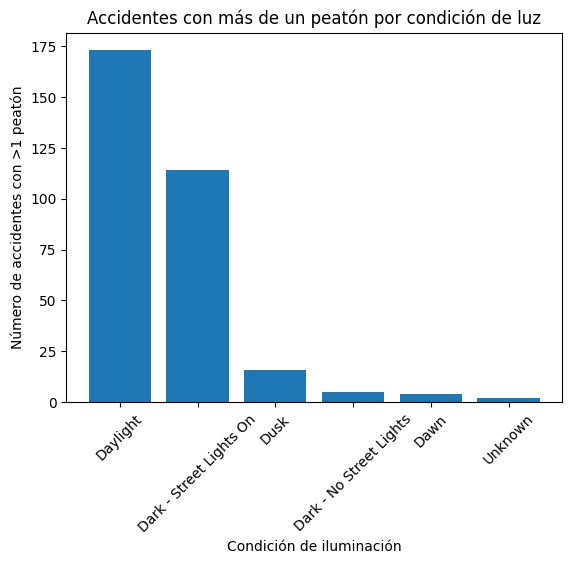

In [74]:
df_peatones = accidentes[accidentes["PEDCOUNT"] > 1]
conteo_luz = df_peatones["LIGHTCOND"].value_counts()

plt.bar(conteo_luz.index, conteo_luz.values)
plt.xlabel("Condición de iluminación")
plt.ylabel("Número de accidentes con >1 peatón")
plt.title("Accidentes con más de un peatón por condición de luz")
plt.xticks(rotation=45)
plt.show()


## Problema 4

Mostrar el número de accidentes totales por año

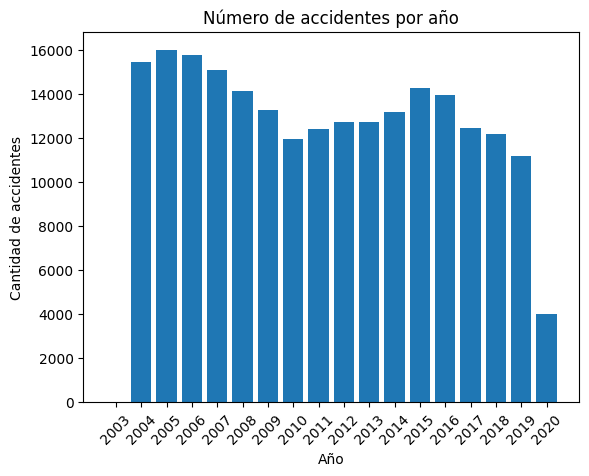

In [75]:
accidentes["INCDATE"] = pd.to_datetime(accidentes["INCDATE"])
accidentes["AÑO"] = accidentes["INCDATE"].dt.year

# Contar número de accidentes por año
accidentes_por_año = accidentes["AÑO"].value_counts().sort_index()

plt.bar(accidentes_por_año.index.astype(str), accidentes_por_año.values)
plt.title("Número de accidentes por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de accidentes")
plt.xticks(rotation=45)
plt.show()

## Problema 5

Realiza un gráfico de dispersión (scatter plot) utilizando las coordenadas geográficas proyectadas de los accidentes (X y Y).


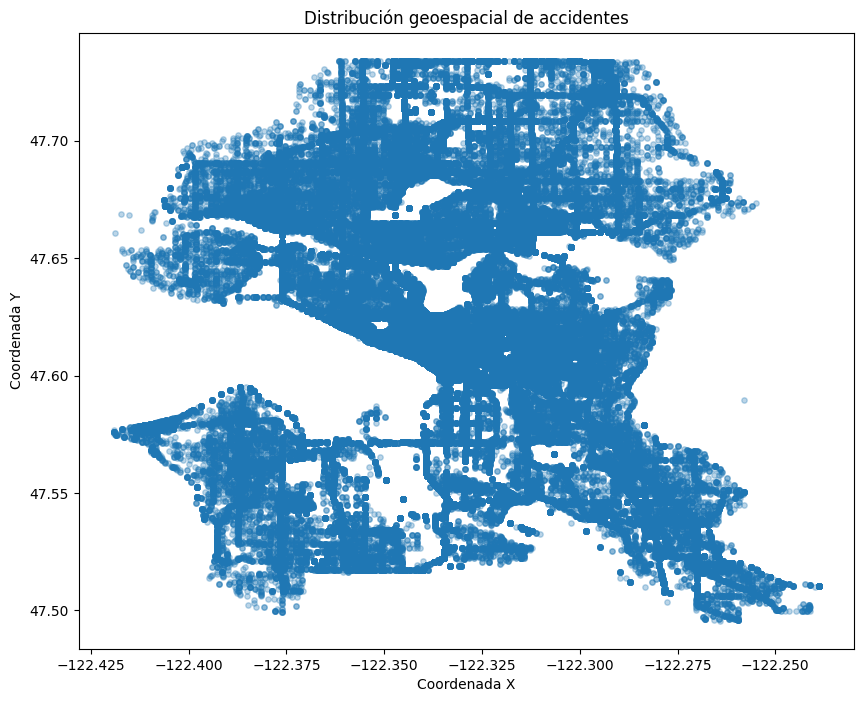

In [76]:
plt.figure(figsize=(10,8))
plt.scatter(accidentes["X"], accidentes["Y"], alpha=0.3, s=15)
plt.xlabel("Coordenada X")
plt.ylabel("Coordenada Y")
plt.title("Distribución geoespacial de accidentes")
plt.show()

# Extra: gráficos interactivos

Existen librerias que generan graficos interactivos de forma fácil :)
Ejemplo : plotly

In [77]:
import plotly.express as px
fig = px.histogram(
    accidentes,
    x="PEDCOUNT"
)
fig.show()

In [ ]:
fig = px.scatter(
    accidentes,
    x="X",
    y="Y",
    title="scatter",
    color="PEDCOUNT"
)
fig.show()

### Sugerencias al momento de presentar gráficos

* Siempre empezar el eje y desde el cero.
* Preocuparse de que el gráfico sea legible. Es decir, que contenga las leyendas pertinentes, que las curvas mostradas se observen bien.
* Uso de color y tipos de línea para dar un correcto énfasis.
* Utilizar paleta de colores adecuada para daltonismo.
* Escoger el gráfico adecuado para lo que se quiere explicar y mostrar.

Para profundizar y guiar sus elecciones de gráficos:


*   [Buenas practicas para la visualización de datos.](https://chartio.com/learn/business-intelligence/5-data-visualization-best-practices/)
*   [Tipos de gráficos esenciales para visualización de datos.](https://www.atlassian.com/data/charts/essential-chart-types-for-data-visualization)



Otra librería para graficar en python:

[Seaborn](https://seaborn.pydata.org/)